<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/Insight-Sogang-Univ/insight-15th/blob/main/advanced/template/session06/practice_transferlearning.ipynb" target="_parent">
      <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
    </a>
  </td>
</table>

# 🚀 전이학습 실습: KoELECTRA Fine-tuning

지난 트랜스포머 실습에서 영화 리뷰 감성 분석을 하기 위해 이 모델을 사용했습니다:

```python
classifier = pipeline("text-classification",
                      model="daekeun-ml/koelectra-small-v3-nsmc")
```

<br>

### **그런데 이 모델은 어떻게 만들어진 걸까요?**

KoELECTRA(Korean ELECTRA)는 한국어 위키백과, 뉴스 등 대규모 말뭉치를 활용해 ELECTRA 방식으로 사전 학습한 한국어 언어 모델입니다!

우리가 실습에 사용했던 모델은 KoELECTRA를 NSMC(네이버 영화 리뷰) 데이터로 전이학습, 파인 튜닝한 모델이죠.

오늘은 베이스 모델(`monologg/koelectra-small-v3-discriminator`)을 직접 NSMC 데이터로 fine-tuning해서, 지난 시간에 썼던 그 모델을 **직접 재현**해봅니다.

그리고 fine-tuning 방식에 따라 결과가 얼마나 달라지는지도 비교해볼 거예요!

<br>

| 오늘 비교할 방식 | 핵심 | 비유 |
|---|---|---|
| 🥶 **Frozen Backbone** | 분류 헤드만 학습 | "메뉴판만 새로 써주세요" |
| 🌡️ **Partial Fine-tuning** | 뒷 레이어만 학습 | "레시피만 새로 익히기" |
| 🔥 **Full Fine-tuning** | 전체 학습 | "완전히 새로운 요리 배우기" |

---
## Step 0. 🧠 강의 개념 먼저 짚고 가기

오늘 실습이 강의에서 배운 어떤 개념인지 확인해봅시다.

### 전이학습 분류

| 구분 | 내용 |
|---|---|
| **전이학습 종류** | 귀납적 전이학습 |
| **왜 귀납적?** | Source task(한국어 사전학습)와 Target task(감성분류)가 **다르기** 때문 |
| **전이하는 것** | 파라미터 전이 (KoELECTRA 사전학습 가중치) |
| **도메인 유사도** | 높음 (한국어 텍스트 → 한국어 텍스트) |
| **데이터양** | 충분 (NSMC 15,000건 사용) |

### 강의자료 표에 따르면?

```
                  데이터 적음              데이터 충분
도메인 유사   →   Frozen Backbone    →   Partial Fine-tuning  ← 우리 상황
도메인 다름   →   처음부터 훈련 고려  →   Full Fine-tuning
```

> 💡 오늘 실험으로 이 표가 실제로 맞는지 직접 확인해봅시다!

---
## Step 1. 📦 라이브러리 설치 & 임포트

In [1]:
!pip install transformers datasets -q
print("✅ 설치 완료!")

✅ 설치 완료!


In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from transformers import AutoTokenizer, ElectraForSequenceClassification
from datasets import load_dataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥️ 사용 디바이스: {device}")
if device.type == "cuda":
    print(f"   GPU: {torch.cuda.get_device_name(0)}")

🖥️ 사용 디바이스: cuda
   GPU: Tesla T4


In [3]:
# 한글 폰트 설정 (Colab)
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

!apt-get install -y fonts-nanum -qq
fm.fontManager.addfont("/usr/share/fonts/truetype/nanum/NanumGothic.ttf")
plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False  # 마이너스 기호 깨짐 방지

Selecting previously unselected package fonts-nanum.
(Reading database ... 122412 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


---
## Step 2. 📥 NSMC 데이터 준비

**NSMC (Naver Sentiment Movie Corpus)**
- 네이버 영화 리뷰 기반 한국어 감성 분류 데이터셋
- 긍정(1) / 부정(0), 총 20만 건
- 오늘은 **학습 15,000건 / 테스트 5,000건**만 사용합니다

In [4]:
import pandas as pd
from datasets import Dataset

# NSMC 데이터를 GitHub에서 직접 로드 (e9t/nsmc 스크립트 방식 우회)
train_df = pd.read_csv(
    "https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt",
    sep="\t"
).dropna()
test_df = pd.read_csv(
    "https://raw.githubusercontent.com/e9t/nsmc/master/ratings_test.txt",
    sep="\t"
).dropna()

# 일부만 사용 (속도용)
train_data = Dataset.from_pandas(train_df.sample(15000, random_state=42).reset_index(drop=True))
test_data  = Dataset.from_pandas(test_df.sample(5000, random_state=42).reset_index(drop=True))

print(f"✅ 학습 데이터: {len(train_data)}건")
print(f"✅ 테스트 데이터: {len(test_data)}건")
print("\n샘플 확인:")
for i in range(3):
    label = "긍정" if train_data[i]["label"] == 1 else "부정"
    print(f"  [{label}] {train_data[i]['document']}")

✅ 학습 데이터: 15000건
✅ 테스트 데이터: 5000건

샘플 확인:
  [긍정] 원본이 최고
  [긍정] 스릴감과 훈훈함이 있는 영화.
  [긍정] 굉장히 저평가되는 영화중 하나라고 생각함


### 토크나이저로 텍스트 → 숫자 변환

In [5]:
MODEL_NAME = "monologg/koelectra-small-v3-discriminator"
tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)

# 토크나이저 동작 확인
sample = "이 영화 진짜 재밌었어요!"
tokens = tokenizer(sample, return_tensors="pt")
print(f"입력 문장: {sample}")
print(f"토큰 문자열: {tokenizer.convert_ids_to_tokens(tokens['input_ids'][0])}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/458 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/61.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

입력 문장: 이 영화 진짜 재밌었어요!
토큰 문자열: ['[CLS]', '이', '영화', '진짜', '재밌', '##었', '##어요', '!', '[SEP]']


In [6]:
def tokenize_fn(examples):
    return tokenizer(
        examples["document"],
        padding="max_length",
        truncation=True,
        max_length=128,
    )

train_enc = train_data.map(tokenize_fn, batched=True)
test_enc  = test_data.map(tokenize_fn,  batched=True)

train_enc.set_format("torch", columns=["input_ids", "attention_mask", "label"])
test_enc.set_format("torch",  columns=["input_ids", "attention_mask", "label"])

train_loader = DataLoader(train_enc, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_enc,  batch_size=64)
print("✅ 데이터 준비 완료!")

Map:   0%|          | 0/15000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

✅ 데이터 준비 완료!


---
## Step 3. 🔧 공통 학습/평가 함수 정의

3가지 방식 모두 동일한 함수를 사용합니다.

In [7]:
def train_one_epoch(model, loader, optimizer, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for batch in loader:
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels         = batch["label"].to(device)

        outputs = model(input_ids=input_ids,
                        attention_mask=attention_mask,
                        labels=labels)
        loss = outputs.loss
        optimizer.zero_grad() #기울기 초기화
        loss.backward() #역전파
        optimizer.step() #가중치 업데이트

        total_loss += loss.item()
        preds    = outputs.logits.argmax(dim=-1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)

    return total_loss / len(loader), correct / total


def evaluate(model, loader, device):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for batch in loader:
            input_ids      = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels         = batch["label"].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            preds    = outputs.logits.argmax(dim=-1)
            correct += (preds == labels).sum().item()
            total   += labels.size(0)
    return correct / total


def run_experiment(freeze_mode, epochs=3, lr=2e-5):
    model = ElectraForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=2
    ).to(device)

    if freeze_mode == "frozen":
        # 분류 헤드(classifier)를 제외한 모든 파라미터 freeze
        for name, param in model.named_parameters():
            if "classifier" not in name:
                param.requires_grad = False #기울기 계산을 끕니다 (Freeze)

    elif freeze_mode == "partial":
        # 임베딩 + 앞 6개 레이어 freeze, 뒤 6개 레이어 + 헤드는 학습
        for name, param in model.named_parameters():
            if "embeddings" in name: #임베딩 레이어를 찾습니다
                param.requires_grad = False
            elif "encoder.layer" in name:
                layer_num = int(name.split("encoder.layer.")[1].split(".")[0])
                param.requires_grad = (layer_num >= 6) #뒤 6개 레이어만 학습시킵니다

    # full은 모든 파라미터 학습 (기본값, freeze 없음)

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total_p   = sum(p.numel() for p in model.parameters())
    print(f"  학습 파라미터: {trainable:,} / {total_p:,} ({trainable/total_p*100:.1f}%)")

    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()), lr=lr
    )

    history = {"train_loss": [], "train_acc": [], "val_acc": []}
    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, device)
        val_acc = evaluate(model, test_loader, device)
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        print(f"  Epoch {epoch+1}/{epochs} | loss={train_loss:.4f} "
              f"| train={train_acc:.3f} | val={val_acc:.3f}")

    return model, history

print("✅ 함수 정의 완료!")

✅ 함수 정의 완료!


---
## Step 4. 🥶 방식 A: Frozen Backbone

> **전체 ELECTRA를 얼리고, 분류 헤드만 학습합니다.**

- 학습 파라미터 ~1% 미만
- 도메인 유사 + 데이터 적을 때 적합
- 학습 빠름, 성능은 제한적

In [8]:
print("🥶 Frozen Backbone 학습 시작")
print("=" * 50)
model_frozen, hist_frozen = run_experiment("frozen", epochs=3, lr=2e-4)
print(f"\n최종 검증 정확도: {hist_frozen['val_acc'][-1]:.3f}")

🥶 Frozen Backbone 학습 시작


pytorch_model.bin:   0%|          | 0.00/56.6M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

ElectraForSequenceClassification LOAD REPORT from: monologg/koelectra-small-v3-discriminator
Key                                               | Status     | 
--------------------------------------------------+------------+-
electra.embeddings.position_ids                   | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
discriminator_predictions.dense.weight            | UNEXPECTED | 
discriminator_predictions.dense.bias              | UNEXPECTED | 
classifier.out_proj.weight                        | MISSING    | 
classifier.dense.bias                             | MISSING    | 
classifier.dense.weight                           | MISSING    | 
classifier.out_proj.bias                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missi

model.safetensors:   0%|          | 0.00/56.5M [00:00<?, ?B/s]

  학습 파라미터: 66,306 / 14,122,498 (0.5%)
  Epoch 1/3 | loss=0.6749 | train=0.577 | val=0.651
  Epoch 2/3 | loss=0.6456 | train=0.628 | val=0.662
  Epoch 3/3 | loss=0.6347 | train=0.641 | val=0.681

최종 검증 정확도: 0.681


---
## Step 5. 🌡️ 방식 B: Partial Fine-tuning

> **앞쪽 6개 레이어는 고정하고, 뒤쪽 6개 레이어 + 헤드만 학습합니다.**

- "앞 레이어 = 일반적 특징 / 뒤 레이어 = task 특화"
- 우리 상황(도메인 유사 + 데이터 충분)의 이론적 최적

In [9]:
print("🌡️ Partial Fine-tuning 학습 시작")
print("=" * 50)
model_partial, hist_partial = run_experiment("partial", epochs=3, lr=2e-5)
print(f"\n최종 검증 정확도: {hist_partial['val_acc'][-1]:.3f}")

🌡️ Partial Fine-tuning 학습 시작


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

ElectraForSequenceClassification LOAD REPORT from: monologg/koelectra-small-v3-discriminator
Key                                               | Status     | 
--------------------------------------------------+------------+-
electra.embeddings.position_ids                   | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
discriminator_predictions.dense.weight            | UNEXPECTED | 
discriminator_predictions.dense.bias              | UNEXPECTED | 
classifier.out_proj.weight                        | MISSING    | 
classifier.dense.bias                             | MISSING    | 
classifier.dense.weight                           | MISSING    | 
classifier.out_proj.bias                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missi

  학습 파라미터: 4,804,866 / 14,122,498 (34.0%)
  Epoch 1/3 | loss=0.5794 | train=0.695 | val=0.787
  Epoch 2/3 | loss=0.4307 | train=0.807 | val=0.811
  Epoch 3/3 | loss=0.3862 | train=0.833 | val=0.812

최종 검증 정확도: 0.812


---
## Step 6. 🔥 방식 C: Full Fine-tuning

> **전체 파라미터를 낮은 학습률로 학습합니다.**

- 가장 강력하지만 학습 시간 & 메모리 가장 많이 필요
- **학습률 낮게 설정** (2e-5) → Catastrophic Forgetting 방지

In [10]:
print("🔥 Full Fine-tuning 학습 시작")
print("=" * 50)
model_full, hist_full = run_experiment("full", epochs=3, lr=2e-5)
print(f"\n최종 검증 정확도: {hist_full['val_acc'][-1]:.3f}")

🔥 Full Fine-tuning 학습 시작


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

ElectraForSequenceClassification LOAD REPORT from: monologg/koelectra-small-v3-discriminator
Key                                               | Status     | 
--------------------------------------------------+------------+-
electra.embeddings.position_ids                   | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
discriminator_predictions.dense.weight            | UNEXPECTED | 
discriminator_predictions.dense.bias              | UNEXPECTED | 
classifier.out_proj.weight                        | MISSING    | 
classifier.dense.bias                             | MISSING    | 
classifier.dense.weight                           | MISSING    | 
classifier.out_proj.bias                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missi

  학습 파라미터: 14,122,498 / 14,122,498 (100.0%)
  Epoch 1/3 | loss=0.5356 | train=0.729 | val=0.816
  Epoch 2/3 | loss=0.3786 | train=0.838 | val=0.832
  Epoch 3/3 | loss=0.3247 | train=0.866 | val=0.841

최종 검증 정확도: 0.841


---
## Step 7. 📊 결과 비교

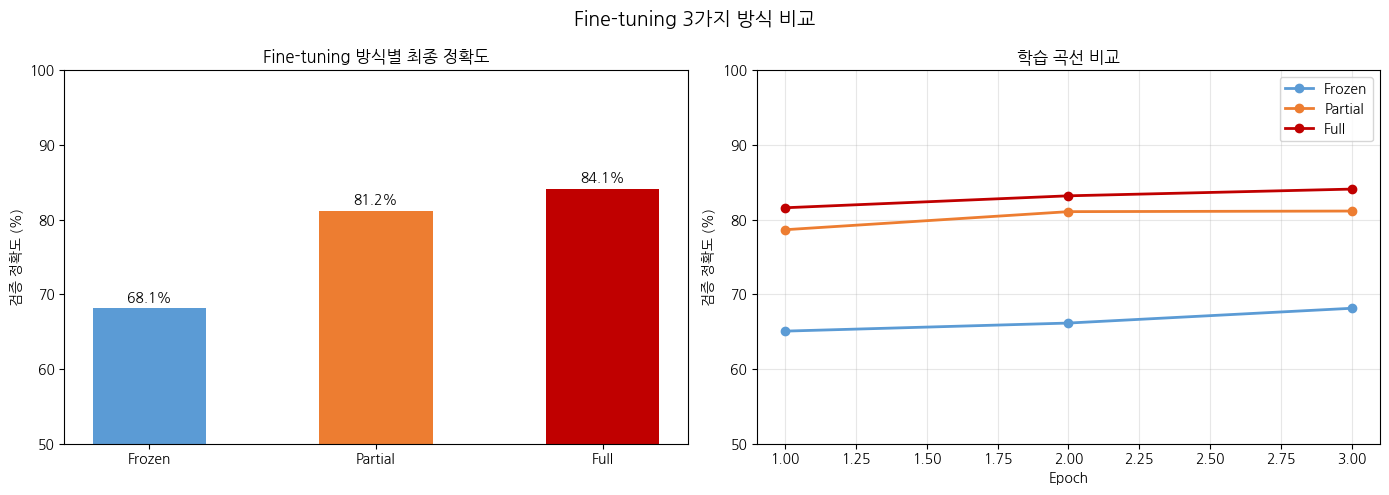


📋 결과 요약
  Frozen  : 68.1%  ███████████████████████████
  Partial : 81.2%  ████████████████████████████████
  Full    : 84.1%  █████████████████████████████████


In [11]:
labels_plot = ["Frozen", "Partial", "Full"]
val_accs    = [hist_frozen["val_acc"][-1],
               hist_partial["val_acc"][-1],
               hist_full["val_acc"][-1]]
colors      = ["#5B9BD5", "#ED7D31", "#C00000"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 막대 그래프
bars = axes[0].bar(labels_plot, [a * 100 for a in val_accs],
                   color=colors, width=0.5)
axes[0].set_ylim(50, 100)
axes[0].set_ylabel("검증 정확도 (%)")
axes[0].set_title("Fine-tuning 방식별 최종 정확도")
for bar, acc in zip(bars, val_accs):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.5,
                 f"{acc*100:.1f}%", ha="center", va="bottom", fontweight="bold")

# 학습 곡선
for hist, label, color in zip(
    [hist_frozen, hist_partial, hist_full], labels_plot, colors
):
    axes[1].plot(range(1, 4), [a * 100 for a in hist["val_acc"]],
                 marker="o", label=label, color=color, linewidth=2)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("검증 정확도 (%)")
axes[1].set_title("학습 곡선 비교")
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].set_ylim(50, 100)

plt.suptitle("Fine-tuning 3가지 방식 비교", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("\n📋 결과 요약")
print("=" * 45)
for label, acc in zip(["Frozen  ", "Partial ", "Full    "], val_accs):
    bar_vis = "█" * int(acc * 40)
    print(f"  {label}: {acc*100:.1f}%  {bar_vis}")
print("=" * 45)

> 💡 **강의자료 표와 대조해보기**
>
> 우리 상황은 **도메인 유사 + 데이터 충분** 이었습니다.  
> 강의자료 표에 따르면 → **Partial Fine-tuning 적합**  
>
> 실험 결과와 일치하나요? 🤔

<details>
<summary> 결과가 나오면 여세요! </summary>
<div markdown="1">

아무래도 Full은 전체 파라미터를 재학습하기 때문에 결과가 좋게 나오지만, 뒤쪽 레이어만 학습한 Partial과 성능 차이가 크게 안 나는 것을 볼 수 있어요!

연산량과 시간을 효율적으로 챙긴 Partial이 현재 상황엔 좋겠죠?

</div>
</details>



---
## Step 8. 🎯 실제 문장으로 3가지 방식 직접 비교

숫자로만 보면 실감이 잘 안 나죠. 실제 문장을 넣어서 비교해봅시다!

In [12]:
def predict(model, text):
    model.eval()
    inputs = tokenizer(
        text, return_tensors="pt",
        padding="max_length", truncation=True, max_length=128,
    ).to(device)
    with torch.no_grad():
        logits = model(**inputs).logits
    probs = torch.softmax(logits, dim=-1)[0]
    pred  = probs.argmax().item() #가장 확률이 높은 클래스 선택 (힌트: arg...)
    label = "긍정 😊" if pred == 1 else "부정 😞"
    return label, probs[pred].item()


test_sentences = [
    "안가은이 정말 예쁘다",
    "돈 아깝다 진짜... 억지 감동에 연기도 별로고 시간 낭비였어요", #원하는 문장으로 수정해 보세요!
    "처음엔 별로였는데 후반부에 반전이 있어서 나쁘지 않았어요",
    "그냥 보통이었어요. 특별히 좋지도 나쁘지도 않은 영화",
]

models_dict = {
    "🥶 Frozen ": model_frozen,
    "🌡️ Partial": model_partial,
    "🔥 Full   ": model_full,
}

print("=" * 65)
for sent in test_sentences:
    print(f"\n📝 {sent}")
    print("-" * 65)
    for name, model in models_dict.items():
        label, score = predict(model, sent)
        print(f"  {name}: {label}  (확신도 {score:.1%})")
print("\n" + "=" * 65)


📝 안가은이 정말 예쁘다
-----------------------------------------------------------------
  🥶 Frozen : 부정 😞  (확신도 50.4%)
  🌡️ Partial: 긍정 😊  (확신도 91.3%)
  🔥 Full   : 긍정 😊  (확신도 96.2%)

📝 돈 아깝다 진짜... 억지 감동에 연기도 별로고 시간 낭비였어요
-----------------------------------------------------------------
  🥶 Frozen : 부정 😞  (확신도 59.9%)
  🌡️ Partial: 부정 😞  (확신도 96.4%)
  🔥 Full   : 부정 😞  (확신도 97.5%)

📝 처음엔 별로였는데 후반부에 반전이 있어서 나쁘지 않았어요
-----------------------------------------------------------------
  🥶 Frozen : 부정 😞  (확신도 51.3%)
  🌡️ Partial: 긍정 😊  (확신도 71.2%)
  🔥 Full   : 긍정 😊  (확신도 90.2%)

📝 그냥 보통이었어요. 특별히 좋지도 나쁘지도 않은 영화
-----------------------------------------------------------------
  🥶 Frozen : 부정 😞  (확신도 55.2%)
  🌡️ Partial: 부정 😞  (확신도 79.7%)
  🔥 Full   : 부정 😞  (확신도 79.2%)



---
## Step 9. 🔁 지난 시간 완성품과 비교

우리가 만든 Fine-tuning 모델 vs 지난 시간에 썼던 `daekeun-ml/koelectra-small-v3-nsmc`

In [13]:
model_original = ElectraForSequenceClassification.from_pretrained(
    "daekeun-ml/koelectra-small-v3-nsmc"
).to(device)

print("원본 모델 vs 우리 Fine-tuning 비교")
print("=" * 65)
for sent in test_sentences:
    label_orig, score_orig = predict(model_original, sent)
    label_our, score_our = predict(model_full, sent) #원하는 모델로 선택해 보세요!
    print(f"\n📝 {sent[:35]}...")
    print(f"  원본 (daekeun): {label_orig}  ({score_orig:.1%})")
    print(f"  우리 Full F-T : {label_our}  ({score_our:.1%})")
print("\n" + "=" * 65)
print("\n✅ 결과가 비슷하다면 성공적으로 재현한 것입니다!")

config.json:   0%|          | 0.00/914 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/56.5M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

ElectraForSequenceClassification LOAD REPORT from: daekeun-ml/koelectra-small-v3-nsmc
Key                             | Status     |  | 
--------------------------------+------------+--+-
electra.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


원본 모델 vs 우리 Fine-tuning 비교

📝 안가은이 정말 예쁘다...
  원본 (daekeun): 긍정 😊  (65.4%)
  우리 Full F-T : 긍정 😊  (96.2%)

📝 돈 아깝다 진짜... 억지 감동에 연기도 별로고 시간 낭비였어요...
  원본 (daekeun): 부정 😞  (99.9%)
  우리 Full F-T : 부정 😞  (97.5%)

📝 처음엔 별로였는데 후반부에 반전이 있어서 나쁘지 않았어요...
  원본 (daekeun): 긍정 😊  (99.9%)
  우리 Full F-T : 긍정 😊  (90.2%)

📝 그냥 보통이었어요. 특별히 좋지도 나쁘지도 않은 영화...
  원본 (daekeun): 부정 😞  (95.5%)
  우리 Full F-T : 부정 😞  (79.2%)


✅ 결과가 비슷하다면 성공적으로 재현한 것입니다!


<details>
<summary> 결과가 나오면 여세요! </summary>
<div markdown="1">

저는 오히려 우리가 만든 게 성능이 좋아 보이네요 ㅎㅎ


=================================================================

📝 이 영화 진짜 재밌었어요! 배우들 연기도 최고고 스토리도 감동적...
  원본 (daekeun): 긍정 😊  (99.9%)
  우리 Full F-T : 긍정 😊  (98.4%)

📝 돈 아깝다 진짜... 억지 감동에 연기도 별로고 시간 낭비였어요...
  원본 (daekeun): 부정 😞  (99.9%)
  우리 Full F-T : 부정 😞  (97.9%)

📝 처음엔 별로였는데 후반부에 반전이 있어서 나쁘지 않았어요...
  원본 (daekeun): 긍정 😊  (99.9%)
  우리 Full F-T : 긍정 😊  (76.4%)

📝 그냥 보통이었어요. 특별히 좋지도 나쁘지도 않은 영화...
  원본 (daekeun): 부정 😞  (95.5%)
  우리 Full F-T : 긍정 😊  (50.3%)

=================================================================

</div>
</details>



---
## (참고) 💡 Fine-tuning의 한계를 넘어서 - PEFT

Full Fine-tuning의 문제점:
- 모델 전체 파라미터를 GPU에 올려야 함 → **메모리 한계**
- GPT-3(175B 파라미터)라면 GPU 수백 장 필요 → **비현실적**

### PEFT (Parameter-Efficient Fine-Tuning)
> "파라미터의 극히 일부만 학습해서, Full Fine-tuning에 가까운 성능 내기"

대표 기법: **LoRA (Low-Rank Adaptation)**

```
일반 Fine-tuning:
  W_new = W_pretrained + ΔW   ← ΔW가 W랑 같은 크기 (무거움)

LoRA:
  W_new = W_pretrained + A × B
  (예: 768×768 행렬 → 768×8 + 8×768 로 분해 → 파라미터 96배 절감!)
```

**현실에서는?**
- 카카오, 네이버 등 기업들이 사내 특화 LLM 만들 때 PEFT 사용
- GPU 1~2장으로 LLaMA, Mistral 같은 오픈소스 LLM fine-tuning 가능
- HuggingFace `peft` 라이브러리로 10줄이면 적용 가능

> 써 보고 싶다면? `pip install peft` 후 LoRA 적용해보기!
> - [PEFT 공식 문서](https://huggingface.co/docs/peft)
> - [LoRA 논문](https://arxiv.org/abs/2106.09685)

### PEFT는 과제에서 다룹니다~ 커밍순!

---
## 오늘 배운 것

| 개념 | 오늘 실습에서 |
|---|---|
| **귀납적 전이학습** | 사전학습(MLM) → 감성분류 (task 다름) |
| **파라미터 전이** | KoELECTRA 가중치를 그대로 활용 |
| **Frozen Backbone** | 헤드만 학습 → 빠르지만 성능 한계 |
| **Partial Fine-tuning** | 뒷 레이어 조정 → 균형 좋음 |
| **Full Fine-tuning** | 전체 학습 → 강력하지만 비용 큼 |
| **PEFT** | Full의 현실적 대안 |


<br>
<br>


## ✏️ 직접 답을 입력해 주세요!

1. **데이터가 100건밖에 없었다면 어떤 방식이 적합했을까요??**  
   → frozen Backbone

2. **도메인이 완전히 달랐다면 어떤 방식이 적합할까요?** (예: 법률 문서, 의료 기록)  
   → Full-Fine-tuning

3. **ELECTRA 말고 BERT(`klue/bert-base`)로 바꾸면?**  
   → `MODEL_NAME` 한 줄만 바꾸면 됩니다. 직접 비교해보세요!

---

# 수고하셨습니다~